# 1. Data Preparation & Cleaning
In this section, we establish the foundation of our forecasting pipeline. We will:
1. Load the raw insurance claims and policyholder datasets.
2. Clean the data by filtering for officially processed (`PAID`) claims.
3. Standardize temporal features (Datetimes).
4. Engineer a highly robust **Weekly Aggregated Time Series** dataset to mitigate the extreme volatility inherent in daily small-data claims.

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

In [140]:
# Load raw datasets

try:
    data_klaim = pd.read_csv('data/Data_Klaim.csv')
    data_polis = pd.read_csv('data/Data_Polis.csv')
    print(f"Data Klaim loaded: {data_klaim.shape[0]} rows, {data_klaim.shape[1]} columns")
    print(f"Data Polis loaded: {data_polis.shape[0]} rows, {data_polis.shape[1]} columns")
except FileNotFoundError:
    print("CSV files not found. Please ensure they are in the 'data/' folder.")

Data Klaim loaded: 4627 rows, 13 columns
Data Polis loaded: 4096 rows, 6 columns


In [141]:
# Data cleaning & temporal standarization

valid_claims = data_klaim[data_klaim['Status Klaim'] == 'PAID'].copy()

# Parse Datetimes
valid_claims['Tanggal Pasien Masuk RS'] = pd.to_datetime(valid_claims['Tanggal Pasien Masuk RS'])
data_polis['Tanggal Lahir'] = pd.to_datetime(data_polis['Tanggal Lahir'])

df_master = pd.merge(valid_claims, data_polis, on='Nomor Polis', how='inner')

df_master['Age_At_Claim'] = ((df_master['Tanggal Pasien Masuk RS'] - df_master['Tanggal Lahir']).dt.days / 365.25).astype(int)

display(df_master.head(3))

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Age_At_Claim
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore,M-001,F,1970-01-01 00:00:00.019670220,20150109,JAKARTA,54
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia,M-002,M,1970-01-01 00:00:00.019560925,20120619,YOGYAKARTA,54
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore,M-002,F,1970-01-01 00:00:00.019591021,20150316,SURABAYA,54


In [142]:
# Weekly Time-Series Aggregation

# Set the date as the index for time-series resampling
ts_data = valid_claims.copy()
ts_data.set_index('Tanggal Pasien Masuk RS', inplace=True)

# Resample to end of week (Sunday)
weekly_df = ts_data.resample('W-SUN').agg(
    Frequency=('Nomor Polis', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

weekly_df.rename(columns={'Tanggal Pasien Masuk RS': 'Week_End_Date'}, inplace=True)

# Derive Severity (Average cost per claim)
# np.where prevents division by zero if a week has 0 claims
weekly_df['Severity'] = np.where(
    weekly_df['Frequency'] > 0, 
    weekly_df['Total_Claim'] / weekly_df['Frequency'], 
    0
)

display(weekly_df.head())

,Week_End_Date,Frequency,Total_Claim,Severity
0,2024-01-07,46,2.484275e+09,5.400597e+07
1,2024-01-14,84,5.887795e+09,7.009280e+07
2,2024-01-21,95,7.601010e+09,8.001063e+07
3,2024-01-28,48,2.042072e+09,4.254317e+07
4,2024-02-04,51,3.791812e+09,7.434926e+07


# 2. Exploratory Data Analysis (EDA) & Data Visualizations
Before modeling, we must understand the underlying dynamics of the insurance claims. The competition brief noted a sudden **25.5% increase in claim volumes** in mid-2025. 

In this section, we will visually investigate:
1. **The Volume Surge:** When exactly did the frequency of claims spike?
2. **Medical Inflation:** Are total costs being driven up by Inpatient (hospital stays) or Outpatient (clinic visits)?
3. **The Danger Matrix:** Which diseases (ICD codes) are bleeding the premium pool the fastest?
4. **Demographic Risk:** Who is submitting these claims?

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14, 'axes.titlesize': 14})

In [144]:
# Clean Month-Year column for macro-level grouping
df_master['Month_Year'] = df_master['Tanggal Pasien Masuk RS'].dt.to_period('M').astype(str)

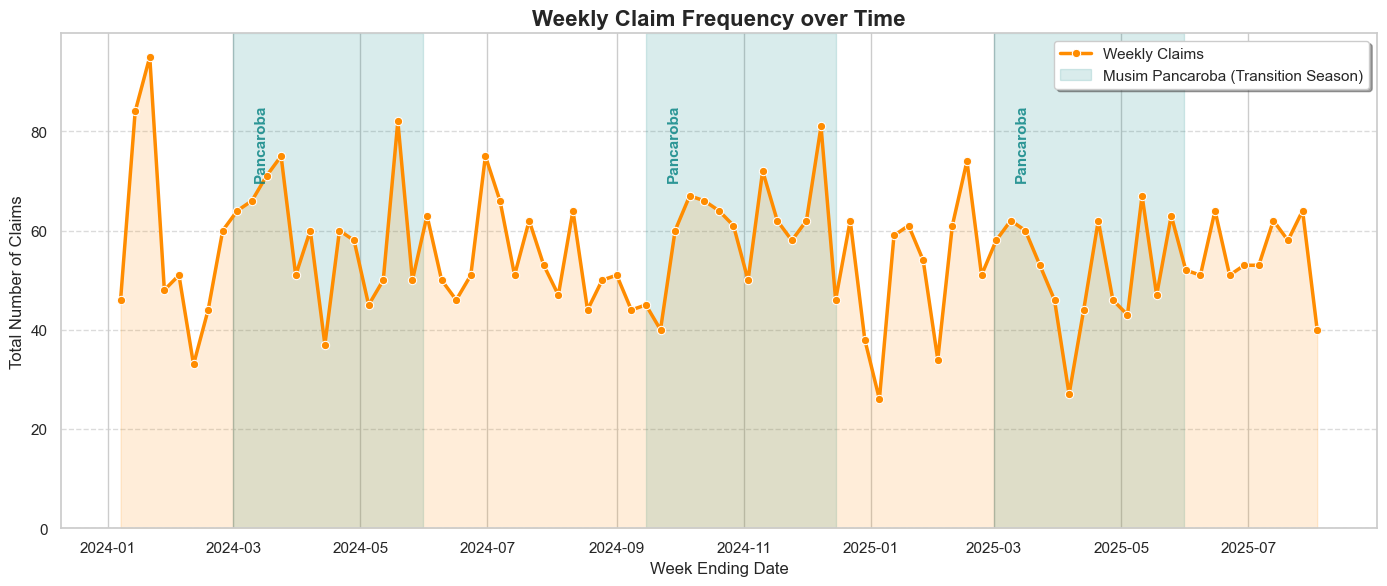

In [145]:
# Claim Frequency over Time

plt.figure(figsize=(14, 6))

# 1. Plot the weekly frequency (zorder=3 ensures the line draws ON TOP of the shading)
sns.lineplot(data=weekly_df, x='Week_End_Date', y='Frequency', 
             marker='o', markersize=6, color='darkorange', linewidth=2.5, zorder=3, label='Weekly Claims')

# 2. Fill the area under the curve
plt.fill_between(weekly_df['Week_End_Date'], weekly_df['Frequency'], 
                 color='darkorange', alpha=0.15, zorder=2)

# 3. Add the "Musim Pancaroba" Highlight Blocks
min_year = weekly_df['Week_End_Date'].dt.year.min()
max_year = weekly_df['Week_End_Date'].dt.year.max()

# Loop through the years in our dataset (2024, 2025) to draw the seasonal bands
for year in range(min_year, max_year + 1):
    # Pancaroba 1: March 1 to May 31
    start_p1 = pd.to_datetime(f'{year}-03-01')
    end_p1 = pd.to_datetime(f'{year}-05-31')
    
    # Pancaroba 2: September 1 to November 30
    start_p2 = pd.to_datetime(f'{year}-09-15')
    end_p2 = pd.to_datetime(f'{year}-12-15')
    
    # Draw Pancaroba 1 (if it falls within our data timeframe)
    if start_p1 <= weekly_df['Week_End_Date'].max() and end_p1 >= weekly_df['Week_End_Date'].min():
        plt.axvspan(start_p1, end_p1, color='teal', alpha=0.15, zorder=1, 
                    label='Musim Pancaroba (Transition Season)' if year == min_year else "")
        plt.text(start_p1 + pd.Timedelta(days=10), weekly_df['Frequency'].max() * 0.9, 
                 'Pancaroba', color='teal', rotation=90, va='top', alpha=0.8, fontweight='bold')

    # Draw Pancaroba 2 (if it falls within our data timeframe)
    if start_p2 <= weekly_df['Week_End_Date'].max() and end_p2 >= weekly_df['Week_End_Date'].min():
        plt.axvspan(start_p2, end_p2, color='teal', alpha=0.15, zorder=1)
        plt.text(start_p2 + pd.Timedelta(days=10), weekly_df['Frequency'].max() * 0.9, 
                 'Pancaroba', color='teal', rotation=90, va='top', alpha=0.8, fontweight='bold')

# 4. Formatting and Styling
plt.title('Weekly Claim Frequency over Time', fontsize=16, fontweight='bold')
plt.xlabel('Week Ending Date', fontsize=12)
plt.ylabel('Total Number of Claims', fontsize=12)
plt.ylim(bottom=0) # Never truncate the Y-axis for volume charts!

# Clean up the legend
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\Robben's Laptop\AppData\Local\Temp\ipykernel_22392\2619943730.py:7: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=trend_data, x='Month_Year', y='Nominal Klaim Yang Disetujui',


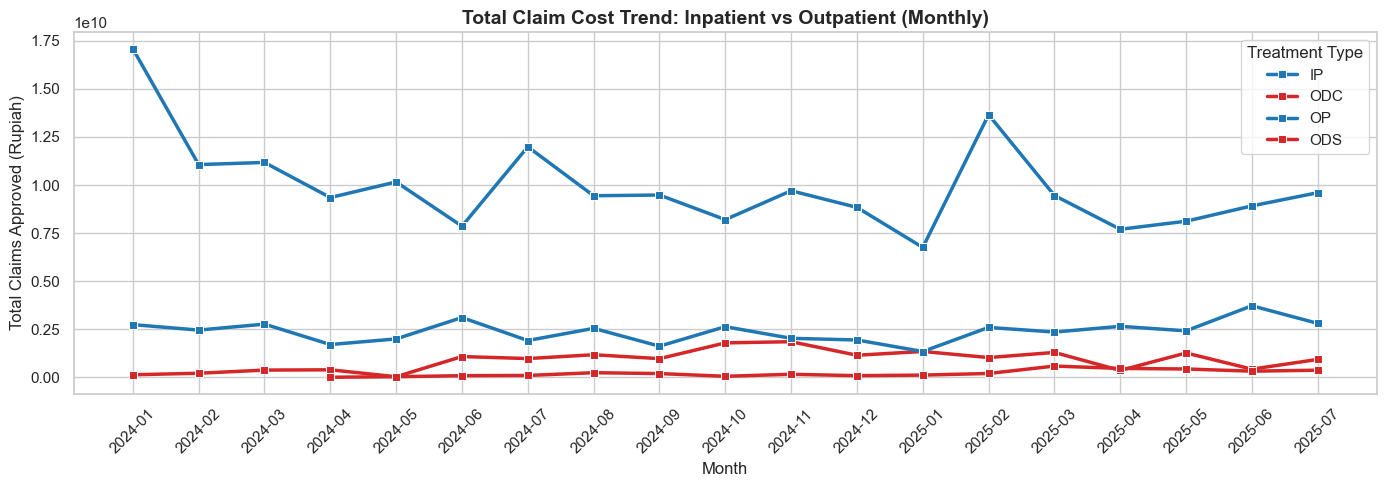

In [146]:
# Inpatient vs Outpatient Costs

# Group total costs by Month and Treatment Type
trend_data = df_master.groupby(['Month_Year', 'Inpatient/Outpatient'])['Nominal Klaim Yang Disetujui'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=trend_data, x='Month_Year', y='Nominal Klaim Yang Disetujui', 
             hue='Inpatient/Outpatient', marker='s', linewidth=2.5, palette=['#1f77b4', '#d62728'])

plt.title('Total Claim Cost Trend: Inpatient vs Outpatient (Monthly)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Claims Approved (Rupiah)')
plt.xticks(rotation=45)
plt.legend(title='Treatment Type')
plt.tight_layout()
plt.show()

# 3. Data Preprocessing & Feature Engineering
With our EDA confirming the high volatility of the claims and the seasonal spikes during *Musim Pancaroba*, we must engineer mathematical features that help our models process these patterns without "exploding."

In this section, we will:
1. **Log-Scaling (The Stability Upgrade):** Compress the massive Rupiah values using $log(1+x)$ to prevent our linear models from compounding errors into infinity.
2. **Time Series Decomposition (DLinear Setup):** Separate the raw data into a slow-moving **Trend** (via Moving Averages) and a chaotic **Remainder**.
3. **Lag Feature Generation:** Create a "memory window" of the past 4 weeks so our Machine Learning models (LightGBM) and Linear Layers can look backward to predict forward.

In [147]:
# Logarithmic transformation

weekly_df['Frequency_Log'] = np.log1p(weekly_df['Frequency'])
weekly_df['Total_Claim_Log'] = np.log1p(weekly_df['Total_Claim'])

print(f"Max Raw Total Claim: {weekly_df['Total_Claim'].max():,.0f}")
print(f"Max Log Total Claim: {weekly_df['Total_Claim_Log'].max():.4f} (Safe for Machine Learning)")

Max Raw Total Claim: 7,934,908,013
Max Log Total Claim: 22.7945 (Safe for Machine Learning)


In [148]:
# Trend & remainder decomposition

window_size = 4 
targets = ['Frequency_Log', 'Total_Claim_Log']

for col in targets:
    # 1. Extract Trend (Moving Average)
    weekly_df[f'{col}_Trend'] = weekly_df[col].rolling(window=window_size).mean()
    
    # 2. Extract Remainder (Raw minus Trend)
    weekly_df[f'{col}_Remain'] = weekly_df[col] - weekly_df[f'{col}_Trend']

display(weekly_df[['Week_End_Date', 'Frequency_Log', 'Frequency_Log_Trend', 'Frequency_Log_Remain']].tail())

,Week_End_Date,Frequency_Log,Frequency_Log_Trend,Frequency_Log_Remain
78,2025-07-06,3.988984,4.025900,-0.036916
79,2025-07-13,4.143135,4.018087,0.125048
80,2025-07-20,4.077537,4.049660,0.027877
81,2025-07-27,4.174387,4.096011,0.078376
82,2025-08-03,3.713572,4.027158,-0.313586


In [149]:
# Lag Feature Engineering

lookback = 4 # 1 month of memory

# 1. Create lags for the RAW metrics (Required for LightGBM and NLinear)
raw_targets = ['Frequency', 'Total_Claim']
for col in raw_targets:
    for lag in range(1, lookback + 1):
        weekly_df[f'{col}_Lag{lag}'] = weekly_df[col].shift(lag)

# 2. Create lags for the LOG DECOMPOSED metrics (Required for DLinear)
log_targets = ['Frequency_Log', 'Total_Claim_Log']
for col in log_targets:
    for lag in range(1, lookback + 1):
        weekly_df[f'{col}_Trend_Lag{lag}'] = weekly_df[f'{col}_Trend'].shift(lag)
        weekly_df[f'{col}_Remain_Lag{lag}'] = weekly_df[f'{col}_Remain'].shift(lag)

print("All Lag features generated successfully.")

All Lag features generated successfully.


In [150]:
# Train split preparation

# Drop the rows with NaNs caused by the rolling window and shifting
train_df = weekly_df.dropna().reset_index(drop=True).copy()

print(f"Final Training Dataset ready! Shape: {train_df.shape[0]} weeks, {train_df.shape[1]} features.")
display(train_df.head(3))

Final Training Dataset ready! Shape: 76 weeks, 34 features.


,Week_End_Date,Frequency,Total_Claim,Severity,Frequency_Log,Total_Claim_Log,Frequency_Log_Trend,Frequency_Log_Remain,Total_Claim_Log_Trend,Total_Claim_Log_Remain,Frequency_Lag1,Frequency_Lag2,Frequency_Lag3,Frequency_Lag4,Total_Claim_Lag1,Total_Claim_Lag2,Total_Claim_Lag3,Total_Claim_Lag4,Frequency_Log_Trend_Lag1,Frequency_Log_Remain_Lag1,Frequency_Log_Trend_Lag2,Frequency_Log_Remain_Lag2,Frequency_Log_Trend_Lag3,Frequency_Log_Remain_Lag3,Frequency_Log_Trend_Lag4,Frequency_Log_Remain_Lag4,Total_Claim_Log_Trend_Lag1,Total_Claim_Log_Remain_Lag1,Total_Claim_Log_Trend_Lag2,Total_Claim_Log_Remain_Lag2,Total_Claim_Log_Trend_Lag3,Total_Claim_Log_Remain_Lag3,Total_Claim_Log_Trend_Lag4,Total_Claim_Log_Remain_Lag4
0,2024-02-25,60,3.765716e+09,6.276193e+07,4.110874,22.049204,3.848785,0.262089,21.688916,0.360288,44.0,33.0,51.0,48.0,3.720538e+09,8.957905e+08,3.791812e+09,2.042072e+09,3.794022,0.012641,3.983443,-0.457083,4.212516,-0.261272,4.187242,-0.295422,21.535923,0.501211,21.714526,-1.101309,22.185259,-0.129149,22.079543,-0.642312
1,2024-03-03,64,4.769555e+09,7.452429e+07,4.174387,22.285519,3.904571,0.269816,21.746268,0.539250,60.0,44.0,33.0,51.0,3.765716e+09,3.720538e+09,8.957905e+08,3.791812e+09,3.848785,0.262089,3.794022,0.012641,3.983443,-0.457083,4.212516,-0.261272,21.688916,0.360288,21.535923,0.501211,21.714526,-1.101309,22.185259,-0.129149
2,2024-03-10,66,2.982524e+09,4.518975e+07,4.204693,21.816036,4.074154,0.130539,22.046973,-0.230937,64.0,60.0,44.0,33.0,4.769555e+09,3.765716e+09,3.720538e+09,8.957905e+08,3.904571,0.269816,3.848785,0.262089,3.794022,0.012641,3.983443,-0.457083,21.746268,0.539250,21.688916,0.360288,21.535923,0.501211,21.714526,-1.101309


# 4. Model Building & Forecasting
In this section, we transition from analyzing the past to predicting the future. We will train **7 distinct models** to forecast the Weekly Frequency and Total Claim amounts from August 2025 to December 2025. 

We structure this systematically to prove why advanced architectures are necessary:
* **Phase 1: The Baselines:** Naive & Seasonal Naive (To establish the absolute performance floor).
* **Phase 2: Statistical Standards:** Pure ARIMA & Auto-SARIMA (To test mathematical momentum).
* **Phase 3: Machine Learning:** LightGBM (To test non-linear tree logic).
* **Phase 4: Advanced Architectures:** NLinear & Log-Scaled DLinear (To handle the 25.5% volatility spike safely).

In [151]:
# The training data ends in July 2025. We must predict August to December 2025.
last_hist_date = weekly_df['Week_End_Date'].max()
target_end_date = pd.to_datetime('2025-12-31')

# Generate the exact sequence of Sundays we need to predict
forecast_weeks = pd.date_range(
    start=last_hist_date + pd.Timedelta(days=7), 
    end=target_end_date + pd.Timedelta(days=7), 
    freq='W-SUN'
)

steps_to_forecast = len(forecast_weeks)
print(f"Targeting {steps_to_forecast} weeks into the future.")

# Create a dictionary to store all our model predictions for easy comparison later
predictions_dict = {'Date': forecast_weeks}

Targeting 22 weeks into the future.


### Model 1 & 2 - The Baselines

In [152]:
# --- 1. NAIVE FORECAST ---
last_freq = weekly_df['Frequency'].iloc[-1]
last_tot = weekly_df['Total_Claim'].iloc[-1]

predictions_dict['Naive_Freq'] = [last_freq] * steps_to_forecast
predictions_dict['Naive_Tot'] = [last_tot] * steps_to_forecast

# --- 2. SEASONAL NAIVE (52-Week Lookback) ---
snaive_freq = []
snaive_tot = []

for week_end in forecast_weeks:
    # Look back exactly 52 weeks (1 year)
    target_past_date = week_end - pd.Timedelta(weeks=52)
    
    # Find that exact week in our historical data
    past_record = weekly_df[weekly_df['Week_End_Date'] == target_past_date]
    
    if not past_record.empty:
        snaive_freq.append(past_record['Frequency'].values[0])
        snaive_tot.append(past_record['Total_Claim'].values[0])
    else:
        # Fallback if the date doesn't exist perfectly
        snaive_freq.append(last_freq) 
        snaive_tot.append(last_tot)

predictions_dict['SNaive_Freq'] = snaive_freq
predictions_dict['SNaive_Tot'] = snaive_tot

### Model 3 - Pure ARIMA

In [153]:
from statsmodels.tsa.arima.model import ARIMA

# We train on the raw sequence (ignoring the log scale for this baseline)
model_arima_freq = ARIMA(weekly_df['Frequency'], order=(1, 1, 1)).fit()
model_arima_tot = ARIMA(weekly_df['Total_Claim'], order=(1, 1, 1)).fit()

# Generate forecasts and ensure no negative predictions
future_arima_freq = model_arima_freq.forecast(steps=steps_to_forecast).values
future_arima_tot = model_arima_tot.forecast(steps=steps_to_forecast).values

predictions_dict['ARIMA_Freq'] = np.maximum(0, future_arima_freq)
predictions_dict['ARIMA_Tot'] = np.maximum(0, future_arima_tot)

print("Pure ARIMA forecasts completed.")

Pure ARIMA forecasts completed.


### Model 4 - Auto-SARIMA

In [154]:
import pmdarima as pm

# Frequency SARIMA
auto_sarima_freq = pm.auto_arima(
    weekly_df['Frequency'], 
    seasonal=True, m=4, 
    suppress_warnings=True, error_action="ignore", trace=False
)

# Total Claim SARIMA
auto_sarima_tot = pm.auto_arima(
    weekly_df['Total_Claim'], 
    seasonal=True, m=4, 
    suppress_warnings=True, error_action="ignore", trace=False
)

predictions_dict['AutoSARIMA_Freq'] = np.maximum(0, auto_sarima_freq.predict(n_periods=steps_to_forecast).values)
predictions_dict['AutoSARIMA_Tot'] = np.maximum(0, auto_sarima_tot.predict(n_periods=steps_to_forecast).values)

### Model 5 - LightGBM

In [155]:
import lightgbm as lgb

print("Training LightGBM Regressors...")

lookback = 4

# --- 1. Train Models ---
features_freq = [f'Frequency_Lag{i}' for i in range(1, lookback + 1)]
model_lgb_freq = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_lgb_freq.fit(train_df[features_freq], train_df['Frequency'])

features_tot = [f'Total_Claim_Lag{i}' for i in range(1, lookback + 1)]
model_lgb_tot = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_lgb_tot.fit(train_df[features_tot], train_df['Total_Claim'])

# --- 2. Recursive Forecasting ---
current_history = weekly_df.copy()
lgbm_freq_preds, lgbm_tot_preds = [], []

for week_end in forecast_weeks:
    last_4 = current_history.tail(lookback)
    
    # Extract lags for prediction
    row_freq = pd.DataFrame([{f'Frequency_Lag{i}': last_4['Frequency'].iloc[-i] for i in range(1, lookback + 1)}])
    row_tot = pd.DataFrame([{f'Total_Claim_Lag{i}': last_4['Total_Claim'].iloc[-i] for i in range(1, lookback + 1)}])
    
    pred_freq = max(0, model_lgb_freq.predict(row_freq)[0])
    pred_tot = max(0, model_lgb_tot.predict(row_tot)[0])
    
    lgbm_freq_preds.append(pred_freq)
    lgbm_tot_preds.append(pred_tot)
    
    # Update history for the next step
    new_row = {'Week_End_Date': week_end, 'Frequency': pred_freq, 'Total_Claim': pred_tot}
    current_history = pd.concat([current_history, pd.DataFrame([new_row])], ignore_index=True)

predictions_dict['LightGBM_Freq'] = lgbm_freq_preds
predictions_dict['LightGBM_Tot'] = lgbm_tot_preds

print("LightGBM forecasts completed.")

Training LightGBM Regressors...
LightGBM forecasts completed.


### Model 6 - NLinear

In [156]:
from sklearn.linear_model import Ridge

print("Training NLinear Architecture...")

# --- 1. Prepare Normalized Training Data ---
train_nl = train_df.copy()
for col in ['Frequency', 'Total_Claim']:
    for lag in range(2, lookback + 1):
        train_nl[f'{col}_Norm_Lag{lag}'] = train_nl[f'{col}_Lag{lag}'] - train_nl[f'{col}_Lag1']
    train_nl[f'{col}_Norm_Target'] = train_nl[col] - train_nl[f'{col}_Lag1']

# --- 2. Train Models ---
model_nl_freq = Ridge(alpha=1.0)
features_nl_freq = [f'Frequency_Norm_Lag{i}' for i in range(2, lookback + 1)]
model_nl_freq.fit(train_nl[features_nl_freq], train_nl['Frequency_Norm_Target'])

model_nl_tot = Ridge(alpha=1.0)
features_nl_tot = [f'Total_Claim_Norm_Lag{i}' for i in range(2, lookback + 1)]
model_nl_tot.fit(train_nl[features_nl_tot], train_nl['Total_Claim_Norm_Target'])

# --- 3. Recursive Forecasting ---
current_history = weekly_df.copy()
nl_freq_preds, nl_tot_preds = [], []

for week_end in forecast_weeks:
    last_4 = current_history.tail(lookback)
    anchor_freq = last_4['Frequency'].iloc[-1]
    anchor_tot = last_4['Total_Claim'].iloc[-1]
    
    row_freq = pd.DataFrame([{f'Frequency_Norm_Lag{i}': last_4['Frequency'].iloc[-i] - anchor_freq for i in range(2, lookback + 1)}])
    row_tot = pd.DataFrame([{f'Total_Claim_Norm_Lag{i}': last_4['Total_Claim'].iloc[-i] - anchor_tot for i in range(2, lookback + 1)}])
    
    # Predict and add the anchor back
    pred_freq = max(0, model_nl_freq.predict(row_freq)[0] + anchor_freq)
    pred_tot = max(0, model_nl_tot.predict(row_tot)[0] + anchor_tot)
    
    nl_freq_preds.append(pred_freq)
    nl_tot_preds.append(pred_tot)
    
    new_row = {'Week_End_Date': week_end, 'Frequency': pred_freq, 'Total_Claim': pred_tot}
    current_history = pd.concat([current_history, pd.DataFrame([new_row])], ignore_index=True)

predictions_dict['NLinear_Freq'] = nl_freq_preds
predictions_dict['NLinear_Tot'] = nl_tot_preds

print("NLinear forecasts completed.")

Training NLinear Architecture...
NLinear forecasts completed.


### Model 7 - Log-Scaled DLinear

In [157]:
print("Training Log-Scaled DLinear Architecture...")

# --- 1. Train Models (Trend & Remain for Log Data) ---
model_params = {'alpha': 1.0}

model_dfreq_trend = Ridge(**model_params)
model_dfreq_trend.fit(train_df[[f'Frequency_Log_Trend_Lag{i}' for i in range(1, 5)]], train_df['Frequency_Log_Trend'])

model_dfreq_remain = Ridge(**model_params)
model_dfreq_remain.fit(train_df[[f'Frequency_Log_Remain_Lag{i}' for i in range(1, 5)]], train_df['Frequency_Log_Remain'])

model_dtot_trend = Ridge(**model_params)
model_dtot_trend.fit(train_df[[f'Total_Claim_Log_Trend_Lag{i}' for i in range(1, 5)]], train_df['Total_Claim_Log_Trend'])

model_dtot_remain = Ridge(**model_params)
model_dtot_remain.fit(train_df[[f'Total_Claim_Log_Remain_Lag{i}' for i in range(1, 5)]], train_df['Total_Claim_Log_Remain'])

# --- 2. Recursive Forecasting ---
current_history = weekly_df.copy()
dl_freq_preds, dl_tot_preds = [], []
window_size = 4

for week_end in forecast_weeks:
    last_4 = current_history.tail(lookback)
    
    # Frequency Predict
    r_freq_t = pd.DataFrame([{f'Frequency_Log_Trend_Lag{i}': last_4['Frequency_Log_Trend'].iloc[-i] for i in range(1, 5)}])
    r_freq_r = pd.DataFrame([{f'Frequency_Log_Remain_Lag{i}': last_4['Frequency_Log_Remain'].iloc[-i] for i in range(1, 5)}])
    pred_freq_log = model_dfreq_trend.predict(r_freq_t)[0] + model_dfreq_remain.predict(r_freq_r)[0]
    pred_freq = max(0, np.expm1(pred_freq_log)) # Convert back from Log
    
    # Total Claim Predict
    r_tot_t = pd.DataFrame([{f'Total_Claim_Log_Trend_Lag{i}': last_4['Total_Claim_Log_Trend'].iloc[-i] for i in range(1, 5)}])
    r_tot_r = pd.DataFrame([{f'Total_Claim_Log_Remain_Lag{i}': last_4['Total_Claim_Log_Remain'].iloc[-i] for i in range(1, 5)}])
    pred_tot_log = model_dtot_trend.predict(r_tot_t)[0] + model_dtot_remain.predict(r_tot_r)[0]
    pred_tot = max(0, np.expm1(pred_tot_log)) # Convert back from Log
    
    dl_freq_preds.append(pred_freq)
    dl_tot_preds.append(pred_tot)
    
    # Update History and Re-Decompose
    new_row = {
        'Week_End_Date': week_end, 'Frequency': pred_freq, 'Total_Claim': pred_tot,
        'Frequency_Log': pred_freq_log, 'Total_Claim_Log': pred_tot_log
    }
    current_history = pd.concat([current_history, pd.DataFrame([new_row])], ignore_index=True)
    
    for col in ['Frequency_Log', 'Total_Claim_Log']:
        current_history[f'{col}_Trend'] = current_history[col].rolling(window=window_size).mean()
        current_history[f'{col}_Remain'] = current_history[col] - current_history[f'{col}_Trend']

predictions_dict['DLinear_Freq'] = dl_freq_preds
predictions_dict['DLinear_Tot'] = dl_tot_preds

print("Log-Scaled DLinear forecasts completed.")

Training Log-Scaled DLinear Architecture...
Log-Scaled DLinear forecasts completed.


# 5. Model Evaluation (Walk-Forward Validation)
To scientifically prove which model performs best, we cannot evaluate them on the training data. Instead, we will perform **Recursive Out-of-Sample Validation** (a form of Walk-Forward Validation).

**Methodology:**
1. We will "hide" the last 8 weeks of our known historical data (June & July 2025).
2. We will train our top models strictly on data from January 2024 to May 2025.
3. We will force the models to predict the hidden 8 weeks recursively.
4. We will compare their predictions against the actual hidden values.

**Evaluation Metrics:**
* **MAPE (Mean Absolute Percentage Error):** The primary Kaggle metric. Measures the relative error percentage.
* **RMSE (Root Mean Squared Error):** Heavily penalizes the model if it misses large inflationary spikes.
* **MAE (Mean Absolute Error):** The average raw Rupiah/Frequency off-target.

In [158]:
# ==========================================
# 1. DEFINE EVALUATION METRICS
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred):
    """Calculates MAE, RMSE, and MAPE for time-series evaluation."""
    # Ensure inputs are numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    
    return round(mae, 2), round(rmse, 2), round(mape, 2)

print("Evaluation metrics initialized.")

Evaluation metrics initialized.


In [159]:
# ==========================================
# 2. WALK-FORWARD VALIDATION (Expanded Roster)
# ==========================================
import lightgbm as lgb
from sklearn.linear_model import Ridge

print("Executing Walk-Forward Validation on all models...")

val_size = 8
cv_train = train_df.iloc[:-val_size].copy()
cv_val = train_df.iloc[-val_size:].copy()

target_col = 'Total_Claim' 
lookback = 4
window_size = 4

# --- A. BASELINE PREPARATIONS ---
# Naive: Just use the last known value before validation started
last_known_val = cv_train[target_col].iloc[-1]
val_naive_preds = [last_known_val] * val_size

# Seasonal Naive (Look back 52 weeks)
val_snaive_preds = []
for week_end in cv_val['Week_End_Date']:
    past_date = week_end - pd.Timedelta(weeks=52)
    past_record = weekly_df[weekly_df['Week_End_Date'] == past_date]
    if not past_record.empty:
        val_snaive_preds.append(past_record[target_col].values[0])
    else:
        val_snaive_preds.append(last_known_val)

# --- B. TRAIN ML & ADVANCED MODELS ON CV SPLIT ---
# LightGBM
features_raw = [f'Total_Claim_Lag{i}' for i in range(1, lookback + 1)]
cv_lgbm = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
cv_lgbm.fit(cv_train[features_raw], cv_train[target_col])

# --- NLinear (Norm Data) ---
# We must dynamically generate the normalized anchor columns for the CV training set
for lag in range(2, lookback + 1):
    cv_train[f'Total_Claim_Norm_Lag{lag}'] = cv_train[f'Total_Claim_Lag{lag}'] - cv_train['Total_Claim_Lag1']
cv_train['Total_Claim_Norm_Target'] = cv_train['Total_Claim'] - cv_train['Total_Claim_Lag1']

cv_nl = Ridge(alpha=1.0)
cv_nl.fit(cv_train[[f'Total_Claim_Norm_Lag{i}' for i in range(2, 5)]], cv_train['Total_Claim_Norm_Target'])

# Log-DLinear
cv_dl_trend = Ridge(alpha=1.0)
cv_dl_trend.fit(cv_train[[f'Total_Claim_Log_Trend_Lag{i}' for i in range(1, 5)]], cv_train['Total_Claim_Log_Trend'])
cv_dl_remain = Ridge(alpha=1.0)
cv_dl_remain.fit(cv_train[[f'Total_Claim_Log_Remain_Lag{i}' for i in range(1, 5)]], cv_train['Total_Claim_Log_Remain'])

# --- C. RECURSIVE PREDICTION LOOP ---
current_history = weekly_df.iloc[:-val_size].copy()
val_lgbm_preds, val_nl_preds, val_dl_preds = [], [], []

for week_end in cv_val['Week_End_Date']:
    last_4 = current_history.tail(lookback)
    anchor = last_4['Total_Claim'].iloc[-1]
    
    # 1. LightGBM
    r_lgb = pd.DataFrame([{f'Total_Claim_Lag{i}': last_4['Total_Claim'].iloc[-i] for i in range(1, 5)}])
    val_lgbm_preds.append(max(0, cv_lgbm.predict(r_lgb)[0]))
    
    # 2. NLinear
    r_nl = pd.DataFrame([{f'Total_Claim_Norm_Lag{i}': last_4['Total_Claim'].iloc[-i] - anchor for i in range(2, 5)}])
    val_nl_preds.append(max(0, cv_nl.predict(r_nl)[0] + anchor))
    
    # 3. DLinear
    r_dl_t = pd.DataFrame([{f'Total_Claim_Log_Trend_Lag{i}': last_4['Total_Claim_Log_Trend'].iloc[-i] for i in range(1, 5)}])
    r_dl_r = pd.DataFrame([{f'Total_Claim_Log_Remain_Lag{i}': last_4['Total_Claim_Log_Remain'].iloc[-i] for i in range(1, 5)}])
    pred_dl_log = cv_dl_trend.predict(r_dl_t)[0] + cv_dl_remain.predict(r_dl_r)[0]
    pred_dl = max(0, np.expm1(pred_dl_log))
    val_dl_preds.append(pred_dl)
    
    # Update History for the loop
    new_row = {'Week_End_Date': week_end, 'Total_Claim': pred_dl, 'Total_Claim_Log': pred_dl_log}
    current_history = pd.concat([current_history, pd.DataFrame([new_row])], ignore_index=True)
    current_history['Total_Claim_Log_Trend'] = current_history['Total_Claim_Log'].rolling(window=window_size).mean()
    current_history['Total_Claim_Log_Remain'] = current_history['Total_Claim_Log'] - current_history['Total_Claim_Log_Trend']

# --- D. THE ENSEMBLE ---
val_ens_preds = (np.array(val_dl_preds) * 0.75) + (np.array(val_lgbm_preds) * 0.25)

print("Validation forecasts successfully generated for all 6 models!")

Executing Walk-Forward Validation on all models...
Validation forecasts successfully generated for all 6 models!


In [162]:
# ==========================================
# 3. THE ULTIMATE SCORECARD
# ==========================================
print("Calculating Performance Metrics on the 8-Week Holdout Set...\n")

actuals = cv_val[target_col].values

# Calculate Metrics for all models
metrics_data = []
for name, preds in [('1. Naive Baseline', val_naive_preds),
                    ('2. Seasonal Naive', val_snaive_preds),
                    ('3. LightGBM', val_lgbm_preds),
                    ('4. NLinear', val_nl_preds),
                    ('5. Log-Scaled DLinear', val_dl_preds),
                    ('6. Ensemble (75/25 Champion)', val_ens_preds)]:
    mae, rmse, mape = calculate_metrics(actuals, preds)
    metrics_data.append([name, mape, rmse, mae])

# Compile Leaderboard
leaderboard = pd.DataFrame(metrics_data, columns=['Model', 'MAPE (%)', 'RMSE', 'MAE'])

# Sort by lowest MAPE to clearly show the winner
leaderboard = leaderboard.sort_values(by='MAPE (%)').reset_index(drop=True)

display(leaderboard.style.background_gradient(cmap='RdYlGn_r', subset=['MAPE (%)', 'RMSE']))

Calculating Performance Metrics on the 8-Week Holdout Set...



,Model,MAPE (%),RMSE,MAE
0,4. NLinear,27.290000,869713537.860000,741978525.750000
1,1. Naive Baseline,27.920000,954885914.470000,826784975.560000
2,5. Log-Scaled DLinear,28.280000,907130935.350000,789055558.270000
3,6. Ensemble (75/25 Champion),29.260000,919456892.600000,789804151.740000
4,3. LightGBM,35.560000,1015545069.090000,891544256.510000
5,2. Seasonal Naive,46.180000,1287541366.680000,1101895427.630000


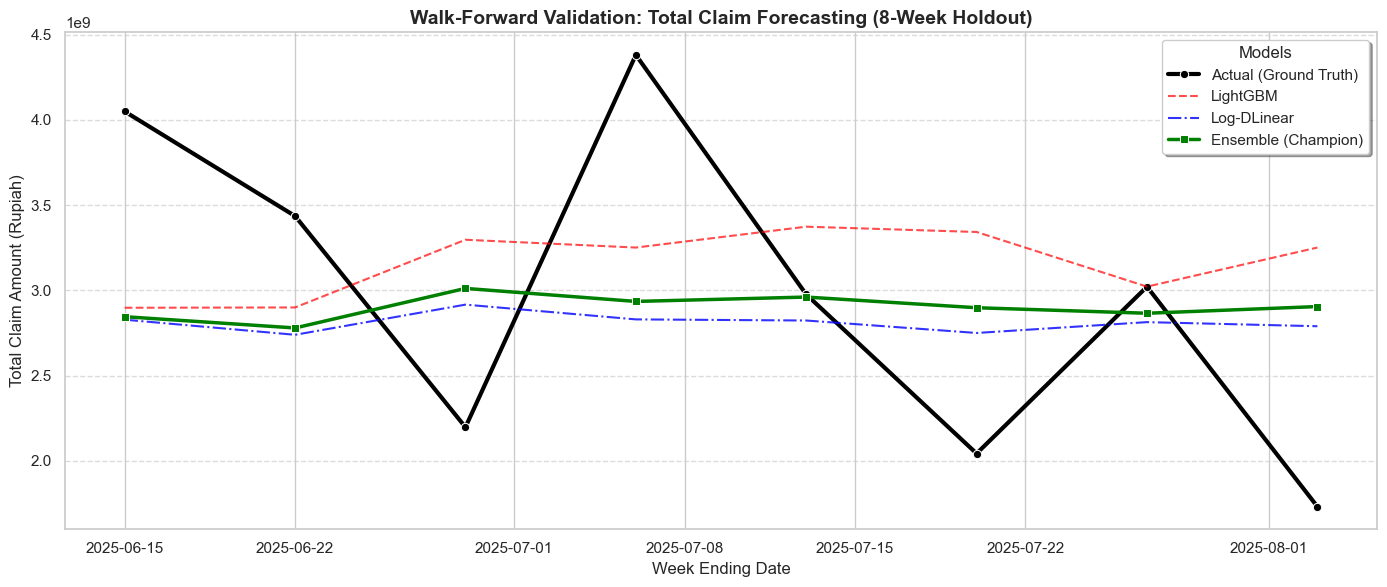

In [163]:
# ==========================================
# 4. PLOTTING THE VALIDATION RESULTS
# ==========================================
# A visual comparison of our models against the ground truth.

plt.figure(figsize=(14, 6))

# Plot the Ground Truth
sns.lineplot(x=cv_val['Week_End_Date'], y=actuals, 
             label='Actual (Ground Truth)', color='black', marker='o', linewidth=3)

# Plot the Models
sns.lineplot(x=cv_val['Week_End_Date'], y=val_lgbm_preds, 
             label='LightGBM', color='red', linestyle='--', alpha=0.7)
sns.lineplot(x=cv_val['Week_End_Date'], y=val_dl_preds, 
             label='Log-DLinear', color='blue', linestyle='-.', alpha=0.8)
sns.lineplot(x=cv_val['Week_End_Date'], y=val_ens_preds, 
             label='Ensemble (Champion)', color='green', marker='s', linewidth=2.5)

plt.title('Walk-Forward Validation: Total Claim Forecasting (8-Week Holdout)', fontweight='bold')
plt.xlabel('Week Ending Date')
plt.ylabel('Total Claim Amount (Rupiah)')
plt.legend(title='Models', shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()